Imports PyTorch + torchvision (for CIFAR-10)

Imports DataLoader (to batch data)

Sets device to GPU if available

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch version:", torch.__version__)

Device: cpu
Torch version: 2.10.0+cpu


CIFAR-10 dataset

Downloads CIFAR-10 automatically into ./data

Creates:

train_set (50,000 images)

test_set (10,000 images)

Converts each image to a tensor using ToTensor()

Important: ToTensor() converts images from:

pixel range 0–255 → float range 0–1

shape becomes (C, H, W) = (3, 32, 32)

In [ ]:
# NO normalization, NO augmentation.
# Loading raw images first.
basic_transform = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=basic_transform
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=basic_transform
)

print("Train size:", len(train_set))
print("Test size:", len(test_set))
print("Class names:", train_set.classes)

100%|██████████| 170M/170M [00:02<00:00, 76.9MB/s]


Train size: 50000
Test size: 10000
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


ONE data sample
x is the image tensor

y is the label (0–9)

x.shape = (3, 32, 32) means:

3 channels (RGB)

32x32 pixels

In [ ]:
x, y = train_set[0]  # first training example

print("x type:", type(x))
print("x shape:", x.shape)          # should be torch.Size([3, 32, 32])
print("x dtype:", x.dtype)          # float32
print("x min/max:", x.min().item(), x.max().item())

print("y:", y)
print("y class name:", train_set.classes[y])

x type: <class 'torch.Tensor'>
x shape: torch.Size([3, 32, 32])
x dtype: torch.float32
x min/max: 0.0 1.0
y: 6
y class name: frog


Display the image - visualize what CIFAR-10 looks like

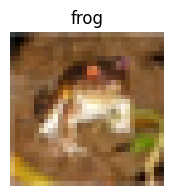

In [ ]:
def show_image(img_tensor, label):
    # img_tensor: (3, 32, 32)
    img = img_tensor.permute(1, 2, 0)  # (H, W, C) for matplotlib
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(train_set.classes[label])
    plt.axis("off")
    plt.show()

show_image(x, y)

Show a grid of multiple images---
CIFAR-10 is small images (32×32)---
Some classes look similar (cat vs dog), which is why it’s challenging

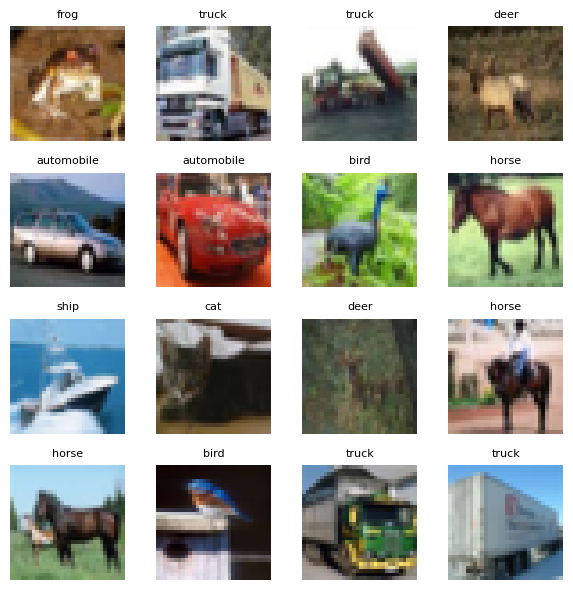

In [ ]:
def show_batch(dataset, n=16):
    plt.figure(figsize=(6,6))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)
        plt.subplot(4, 4, i+1)
        plt.imshow(img)
        plt.title(train_set.classes[label], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_set, n=16)

DataLoader

Instead of feeding 1 image at a time, training uses batches

xb.shape = (128, 3, 32, 32) means 128 images at once

In [ ]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)  # (batch_size, 3, 32, 32)
print("Batch label shape:", yb.shape)  # (batch_size,)
print("First 10 labels:", yb[:10].tolist())

Batch image shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
First 10 labels: [2, 6, 3, 4, 3, 5, 0, 0, 5, 4]


check class balance

In [ ]:
from collections import Counter

labels = [train_set[i][1] for i in range(len(train_set))]
counts = Counter(labels)

for k in range(10):
    print(train_set.classes[k], ":", counts[k])

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


Flatten the image (turn 3×32×32 into 3072 numbers)

A fully connected network expects a 2D input: (batch, features)

CIFAR image (3,32,32) → 3*32*32 = 3072 features

Now you have (B, 3072)

In [ ]:

xb, yb = next(iter(train_loader))  # xb: (B, 3, 32, 32)

print("Before flatten:", xb.shape)

xb_flat = xb.view(xb.shape[0], -1)  # (B, 3072)

print("After flatten:", xb_flat.shape)
print("One image becomes length:", xb_flat.shape[1])

Before flatten: torch.Size([128, 3, 32, 32])
After flatten: torch.Size([128, 3072])
One image becomes length: 3072


Manual Fully Connected (Linear) layer

Creates parameters W and b

Forward: x @ W + b

Backward computes:

dW, db (how to change weights/bias)

dx (gradient to pass to previous layer)

In [ ]:
# Built in connected layer
# import torch
# import torch.nn as nn

# # Create built-in fully connected layer
# fc = nn.Linear(in_features=3072, out_features=256)

# # Example input (batch of 128 images flattened)
# x = torch.randn(128, 3072)

# # Forward pass
# out = fc(x)

# print("Output shape:", out.shape)

class Linear:
    def __init__(self, in_features, out_features, weight_scale=0.01, device="cpu"):
        self.W = weight_scale * torch.randn(in_features, out_features, device=device) # build it
        self.b = torch.zeros(out_features, device=device) # built in

        # gradients (filled during backward)
        self.dW = torch.zeros_like(self.W)
        self.db = torch.zeros_like(self.b)

        # cache input for backward
        self.x = None

    def forward(self, x):
        # x: (N, D)
        self.x = x
        return x @ self.W + self.b  # (N, M)

    def backward(self, dout):
        # dout: (N, M)
        self.dW = self.x.t() @ dout          # (D, M)
        self.db = dout.sum(dim=0)            # (M,)
        dx = dout @ self.W.t()               # (N, D)
        return dx

Manual ReLU

Forward: removes negatives

Backward: only passes gradient where input was positive


In [ ]:
class ReLU:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x > 0)
        return x * self.mask

    def backward(self, dout):
        return dout * self.mask

Softmax + Cross-Entropy loss

Converts logits → probabilities (softmax)

Computes loss (how wrong the model is)

Returns gradient dlogits which starts backprop

In [ ]:
def softmax(logits):
    # logits: (N, C)
    z = logits - logits.max(dim=1, keepdim=True).values  # stability trick
    exp = torch.exp(z)
    return exp / exp.sum(dim=1, keepdim=True)

def cross_entropy_loss_from_logits(logits, y):
    """
    logits: (N, C)
    y: (N,) integer labels
    returns: (loss scalar, dlogits)
    """
    N, C = logits.shape
    probs = softmax(logits)

    eps = 1e-12
    correct_probs = probs[torch.arange(N), y]  # probability of correct class
    loss = (-torch.log(correct_probs + eps)).mean()

    # gradient of loss w.r.t logits
    dlogits = probs.clone()
    dlogits[torch.arange(N), y] -= 1.0
    dlogits /= N
    return loss, dlogits

FC Neural Network model

Combines layers into a model

Forward produces logits

Backward propagates gradients through layers

params() returns all weights and gradients so we can update them


In [ ]:
class FCNet:
    def __init__(self, input_dim=3072, hidden_dim=256, num_classes=10, device="cpu"):
        self.fc1 = Linear(input_dim, hidden_dim, device=device)
        self.relu = ReLU()
        self.fc2 = Linear(hidden_dim, num_classes, device=device)

    def forward(self, x):
        # x: (N, 3, 32, 32)
        x = x.view(x.shape[0], -1)      # flatten
        x = self.fc1.forward(x)
        x = self.relu.forward(x)
        logits = self.fc2.forward(x)
        return logits

    def backward(self, dlogits):
        dx = self.fc2.backward(dlogits)
        dx = self.relu.backward(dx)
        dx = self.fc1.backward(dx)
        return dx

    def params(self):
        # return list of parameters and grads for updating
        return [
            (self.fc1.W, self.fc1.dW),
            (self.fc1.b, self.fc1.db),
            (self.fc2.W, self.fc2.dW),
            (self.fc2.b, self.fc2.db),
        ]

Manual gradient descent update

In [ ]:
def sgd_step(params, lr=0.1):
    for p, dp in params:
        p -= lr * dp

Accuracy function

In [ ]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

Training loop

Trains for multiple epochs

Each iteration:

forward

loss

backward

update

Stores:

loss_history (per batch/iteration)

train/test accuracy (per epoch)

In [ ]:
def train_fc(model, train_loader, test_loader, epochs=5, lr=0.1, device="cpu"):
    loss_history = []      # loss per iteration
    train_acc_hist = []    # train acc per epoch
    test_acc_hist = []     # test acc per epoch

    for epoch in range(1, epochs + 1):
        model_loss = 0.0
        model_acc = 0.0
        steps = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # forward
            logits = model.forward(xb)

            # loss + gradient start
            loss, dlogits = cross_entropy_loss_from_logits(logits, yb)

            # backward
            model.backward(dlogits)

            # update
            sgd_step(model.params(), lr=lr)

            # log
            loss_history.append(loss.item())
            model_loss += loss.item()
            model_acc += accuracy_from_logits(logits, yb)
            steps += 1

        # epoch summary
        train_acc = model_acc / steps
        train_acc_hist.append(train_acc)

        # test accuracy
        test_acc = evaluate(model, test_loader, device=device)
        test_acc_hist.append(test_acc)

        print(f"Epoch {epoch}: train_loss={model_loss/steps:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

    return loss_history, train_acc_hist, test_acc_hist

@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    acc_sum = 0.0
    steps = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model.forward(xb)
        acc_sum += accuracy_from_logits(logits, yb)
        steps += 1
    return acc_sum / steps

Run training - Small

In [ ]:
model = FCNet(device=device)
loss_hist, train_acc_hist, test_acc_hist = train_fc(
    model, train_loader, test_loader,
    epochs=5, lr=0.1, device=device
)

Epoch 1: train_loss=1.9866 train_acc=0.2779 test_acc=0.3722
Epoch 2: train_loss=1.7895 train_acc=0.3599 test_acc=0.3482
Epoch 3: train_loss=1.7224 train_acc=0.3881 test_acc=0.3697
Epoch 4: train_loss=1.6647 train_acc=0.4087 test_acc=0.3748
Epoch 5: train_loss=1.6177 train_acc=0.4252 test_acc=0.3734


PlOT THE 3 required graphs

We did NOT use torch.nn.Linear, torch.nn.ReLU, torch.optim, CrossEntropyLoss

We only used:

DataLoader and CIFAR dataset (allowed)

Basic tensor operations (these are fine)

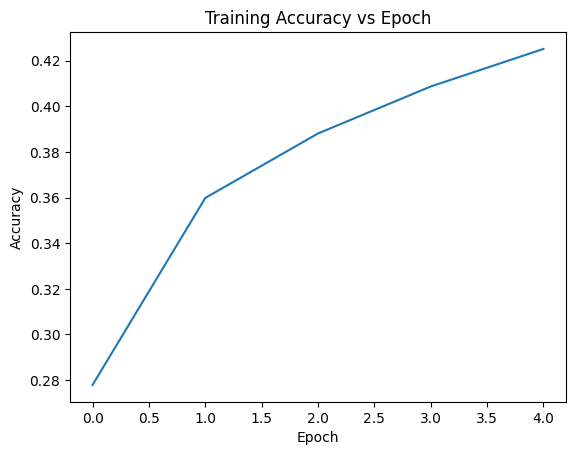

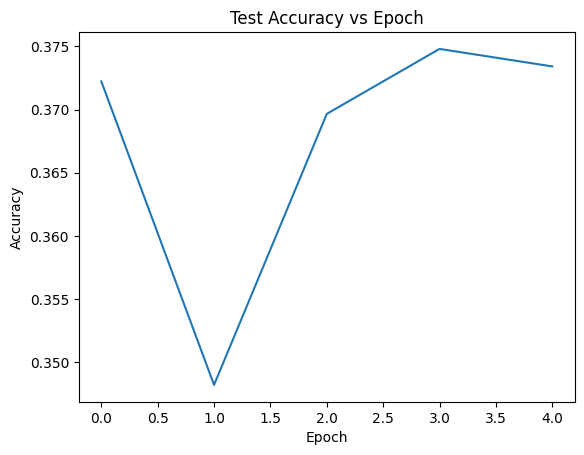

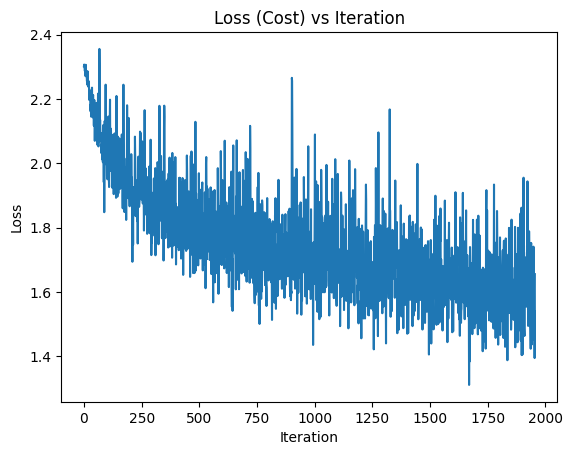

In [ ]:
# 1) Training accuracy vs epoch
plt.figure()
plt.plot(train_acc_hist)
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 2) Test accuracy vs epoch
plt.figure()
plt.plot(test_acc_hist)
plt.title("Test Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# 3) Loss vs iteration
plt.figure()
plt.plot(loss_hist)
plt.title("Loss (Cost) vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()